# Raw EDA — Factory Space Prices (2023–2025)

**Objective**: Understand the raw dataset before any cleaning or feature engineering.

We'll cover:
1. Data shape & types
2. Missing values
3. Duplicates
4. Descriptive statistics
5. Target variable distribution
6. Categorical feature overview
7. Numeric feature distributions
8. Initial observations & issues to address

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

In [ ]:


DATA_PATH = "../data/raw/factory_2023_2025.csv"
df = pd.read_csv(DATA_PATH)

# Drop footnote/caveat rows at the bottom of the CSV
df = df[df["Contract Date"].str.match(r"^\d{2}/\d{2}/\d{4}$", na=False)].reset_index(drop=True)

print(f"Shape: {df.shape}")
df.head()

Shape: (4615, 15)


,Contract Date,Project Name,Street Name,Property Type,Type Of Area,Area (sqft),Floor Level,Price,Unit Price ($ psf),Tenure,Type of Sale,Region,Planning Area,Postal District,Postal Sector
0,31/12/2025,CT FOODNEX,MANDAI ESTATE,Multiple-User Factory,Strata,"3,724",First Floor,"4,100,000","1,101",Freehold,Resale,North Region,Sungei Kadut,25.0,72.0
1,30/12/2025,VALIANT INDUSTRIAL BUILDING,KALLANG PUDDING ROAD,Multiple-User Factory,Strata,"2,088",Non-First Floor,"1,618,200",775,Freehold,Resale,Central Region,Geylang,13.0,34.0
2,30/12/2025,PREMIER @ KAKI BUKIT,KAKI BUKIT AVENUE 4,Multiple-User Factory,Strata,"1,098",Non-First Floor,"680,000",619,60 yrs from 15/12/2010,Resale,East Region,Bedok,14.0,41.0
3,30/12/2025,FOCUS ONE,UBI VIEW,Multiple-User Factory,Strata,"5,371",Non-First Floor,"2,500,000",465,60 yrs from 04/01/1999,Resale,Central Region,Geylang,14.0,40.0
4,30/12/2025,GOURMET EAST KITCHEN,BEDOK NORTH STREET 5,Multiple-User Factory,Strata,"2,885",Non-First Floor,"641,800",222,30 yrs from 01/04/2002,Resale,East Region,Tampines,16.0,48.0


## 1. Data Types & Info

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4615 entries, 0 to 4614
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Contract Date       4615 non-null   str    
 1   Project Name        4577 non-null   str    
 2   Street Name         4615 non-null   str    
 3   Property Type       4615 non-null   str    
 4   Type Of Area        4615 non-null   str    
 5   Area (sqft)         4615 non-null   str    
 6   Floor Level         4615 non-null   str    
 7   Price               4615 non-null   str    
 8   Unit Price ($ psf)  4615 non-null   str    
 9   Tenure              4615 non-null   str    
 10  Type of Sale        4615 non-null   str    
 11  Region              4615 non-null   str    
 12  Planning Area       4615 non-null   str    
 13  Postal District     4615 non-null   float64
 14  Postal Sector       4615 non-null   float64
dtypes: float64(2), str(13)
memory usage: 540.9 KB


In [3]:
df.dtypes

Contract Date             str
Project Name              str
Street Name               str
Property Type             str
Type Of Area              str
Area (sqft)               str
Floor Level               str
Price                     str
Unit Price ($ psf)        str
Tenure                    str
Type of Sale              str
Region                    str
Planning Area             str
Postal District       float64
Postal Sector         float64
dtype: object

## 2. Missing Values

In [4]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"Missing Count": missing, "Missing %": missing_pct})
missing_df[missing_df["Missing Count"] > 0].sort_values("Missing %", ascending=False)

,Missing Count,Missing %
Project Name,38,0.82


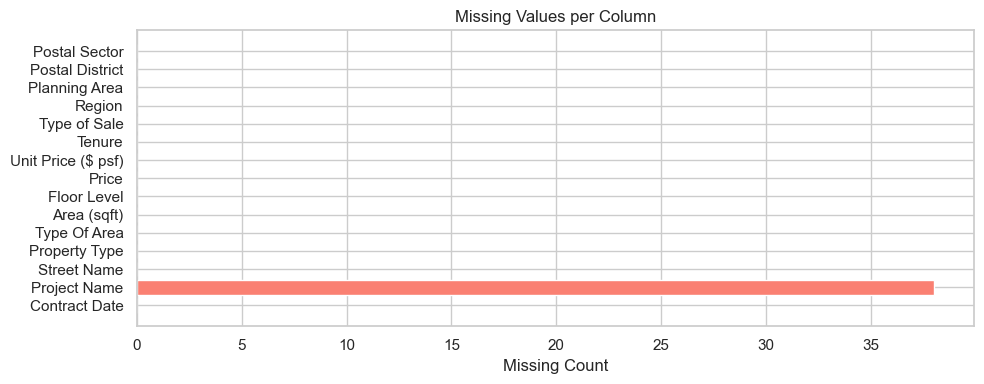

In [5]:
# Visualise missing values
fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(df.columns, df.isnull().sum(), color="salmon")
ax.set_xlabel("Missing Count")
ax.set_title("Missing Values per Column")
plt.tight_layout()
plt.show()

## 3. Duplicates

In [6]:
n_dupes = df.duplicated().sum()
print(f"Exact duplicate rows: {n_dupes} ({n_dupes / len(df) * 100:.2f}%)")

if n_dupes > 0:
    print("\nSample duplicates:")
    display(df[df.duplicated(keep=False)].sort_values(df.columns.tolist()).head(10))

Exact duplicate rows: 106 (2.30%)

Sample duplicates:


,Contract Date,Project Name,Street Name,Property Type,Type Of Area,Area (sqft),Floor Level,Price,Unit Price ($ psf),Tenure,Type of Sale,Region,Planning Area,Postal District,Postal Sector
3751,01/08/2023,NORTH SPRING BIZHUB,YISHUN INDUSTRIAL STREET 1,Multiple-User Factory,Strata,"1,539",First Floor,"850,000",552,60 yrs from 01/02/2011,Resale,North Region,Yishun,27.0,76.0
3752,01/08/2023,NORTH SPRING BIZHUB,YISHUN INDUSTRIAL STREET 1,Multiple-User Factory,Strata,"1,539",First Floor,"850,000",552,60 yrs from 01/02/2011,Resale,North Region,Yishun,27.0,76.0
3235,01/12/2023,WOODLANDS 11,WOODLANDS CLOSE,Multiple-User Factory,Strata,"1,938",Non-First Floor,"855,000",441,60 yrs from 05/07/2010,Resale,North Region,Woodlands,25.0,73.0
3236,01/12/2023,WOODLANDS 11,WOODLANDS CLOSE,Multiple-User Factory,Strata,"1,938",Non-First Floor,"855,000",441,60 yrs from 05/07/2010,Resale,North Region,Woodlands,25.0,73.0
4418,02/03/2023,VERTEX,UBI AVENUE 3,Multiple-User Factory,Strata,"2,239",Non-First Floor,"1,250,000",558,60 yrs from 01/01/2007,Resale,Central Region,Geylang,14.0,40.0
4419,02/03/2023,VERTEX,UBI AVENUE 3,Multiple-User Factory,Strata,"2,239",Non-First Floor,"1,250,000",558,60 yrs from 01/01/2007,Resale,Central Region,Geylang,14.0,40.0
772,02/07/2025,WEST CONNECT BUILDING,BUROH STREET,Multiple-User Factory,Strata,"1,733",First Floor,"760,000",439,30 yrs from 29/04/2013,Resale,West Region,Boon Lay,22.0,62.0
773,02/07/2025,WEST CONNECT BUILDING,BUROH STREET,Multiple-User Factory,Strata,"1,733",First Floor,"760,000",439,30 yrs from 29/04/2013,Resale,West Region,Boon Lay,22.0,62.0
3490,02/10/2023,NORTH LINK BUILDING,ADMIRALTY STREET,Multiple-User Factory,Strata,"5,188",Non-First Floor,"1,150,000",222,60 yrs from 09/10/1999,Resale,North Region,Sembawang,27.0,75.0
3491,02/10/2023,NORTH LINK BUILDING,ADMIRALTY STREET,Multiple-User Factory,Strata,"5,188",Non-First Floor,"1,150,000",222,60 yrs from 09/10/1999,Resale,North Region,Sembawang,27.0,75.0


## 4. Descriptive Statistics

In [7]:
# Note: Area, Price, Unit Price are read as strings due to commas — describe object cols too
df.describe(include="all")

,Contract Date,Project Name,Street Name,Property Type,Type Of Area,Area (sqft),Floor Level,Price,Unit Price ($ psf),Tenure,Type of Sale,Region,Planning Area,Postal District,Postal Sector
count,4615,4577,4615,4615,4615,4615,4615,4615,4615,4615,4615,4615,4615,4615.000000,4615.000000
unique,745,249,135,1,2,581,3,1354,1033,130,3,5,27,NaN,NaN
top,30/09/2025,MIDVIEW CITY,WOODLANDS CLOSE,Multiple-User Factory,Strata,"1,711",Non-First Floor,"500,000",310,Freehold,Resale,Central Region,Geylang,NaN,NaN
freq,19,144,285,4615,4586,110,3986,56,30,672,4479,1417,848,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19.365980,55.051138
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.084595,16.808232
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.000000,11.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.000000,40.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22.000000,60.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25.000000,72.000000


## 5. Unique Values per Column

In [8]:
for col in df.columns:
    n_unique = df[col].nunique()
    print(f"{col}: {n_unique} unique values")
    if n_unique <= 15:
        print(f"  → {df[col].value_counts().to_dict()}")
    print()

Contract Date: 745 unique values

Project Name: 249 unique values

Street Name: 135 unique values

Property Type: 1 unique values
  → {'Multiple-User Factory': 4615}

Type Of Area: 2 unique values
  → {'Strata': 4586, 'Land': 29}

Area (sqft): 581 unique values

Floor Level: 3 unique values
  → {'Non-First Floor': 3986, 'First Floor': 506, '-': 123}

Price: 1354 unique values

Unit Price ($ psf): 1033 unique values

Tenure: 130 unique values

Type of Sale: 3 unique values
  → {'Resale': 4479, 'New Sale': 135, 'Subsale': 1}

Region: 5 unique values
  → {'Central Region': 1417, 'West Region': 1268, 'North Region': 1162, 'East Region': 453, 'North-East Region': 315}

Planning Area: 27 unique values

Postal District: 16 unique values

Postal Sector: 32 unique values



## 6. Target Variable — Price Distribution

Since Price is stored as a string with commas, we'll convert it temporarily for visualisation.

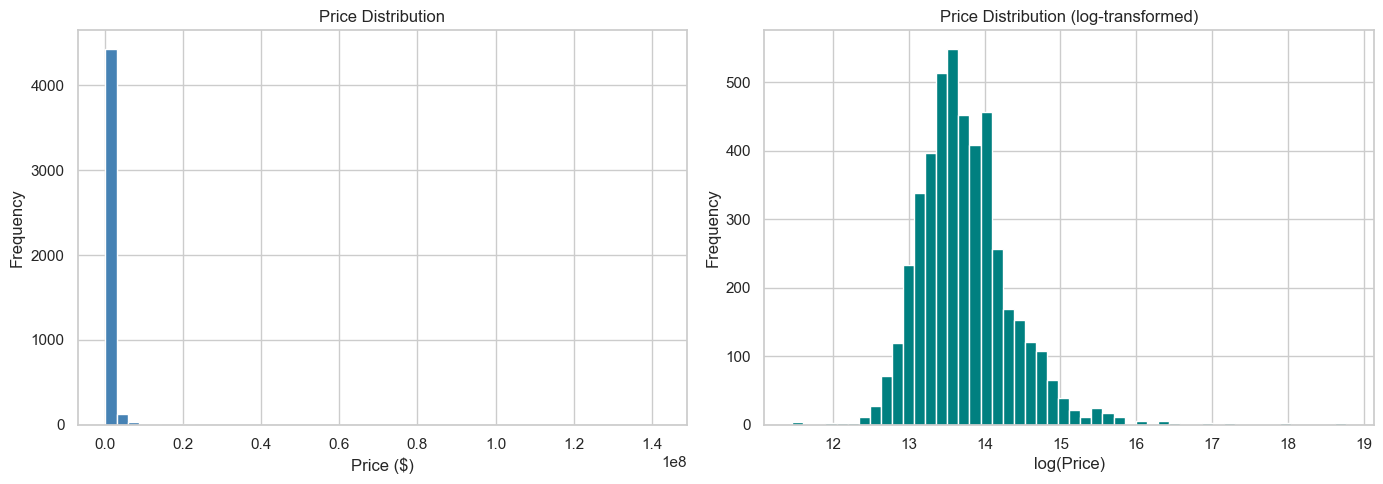

Min: $95,000
Max: $142,000,000
Mean: $1,334,317
Median: $863,000
Skewness: 24.70


In [9]:
price_numeric = df["Price"].str.replace(",", "").astype(float)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(price_numeric, bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("Price Distribution")
axes[0].set_xlabel("Price ($)")
axes[0].set_ylabel("Frequency")

# Log-transformed histogram
axes[1].hist(np.log1p(price_numeric), bins=50, color="teal", edgecolor="white")
axes[1].set_title("Price Distribution (log-transformed)")
axes[1].set_xlabel("log(Price)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

print(f"Min: ${price_numeric.min():,.0f}")
print(f"Max: ${price_numeric.max():,.0f}")
print(f"Mean: ${price_numeric.mean():,.0f}")
print(f"Median: ${price_numeric.median():,.0f}")
print(f"Skewness: {price_numeric.skew():.2f}")

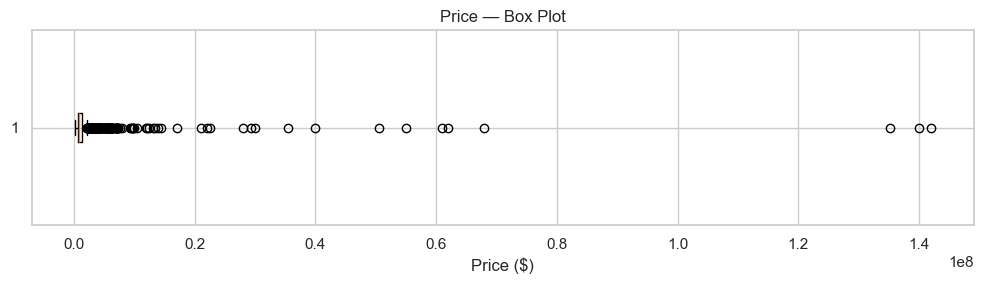

In [10]:
# Box plot for outlier detection
fig, ax = plt.subplots(figsize=(10, 3))
ax.boxplot(price_numeric, vert=False)
ax.set_xlabel("Price ($)")
ax.set_title("Price — Box Plot")
plt.tight_layout()
plt.show()

## 7. Categorical Features Overview

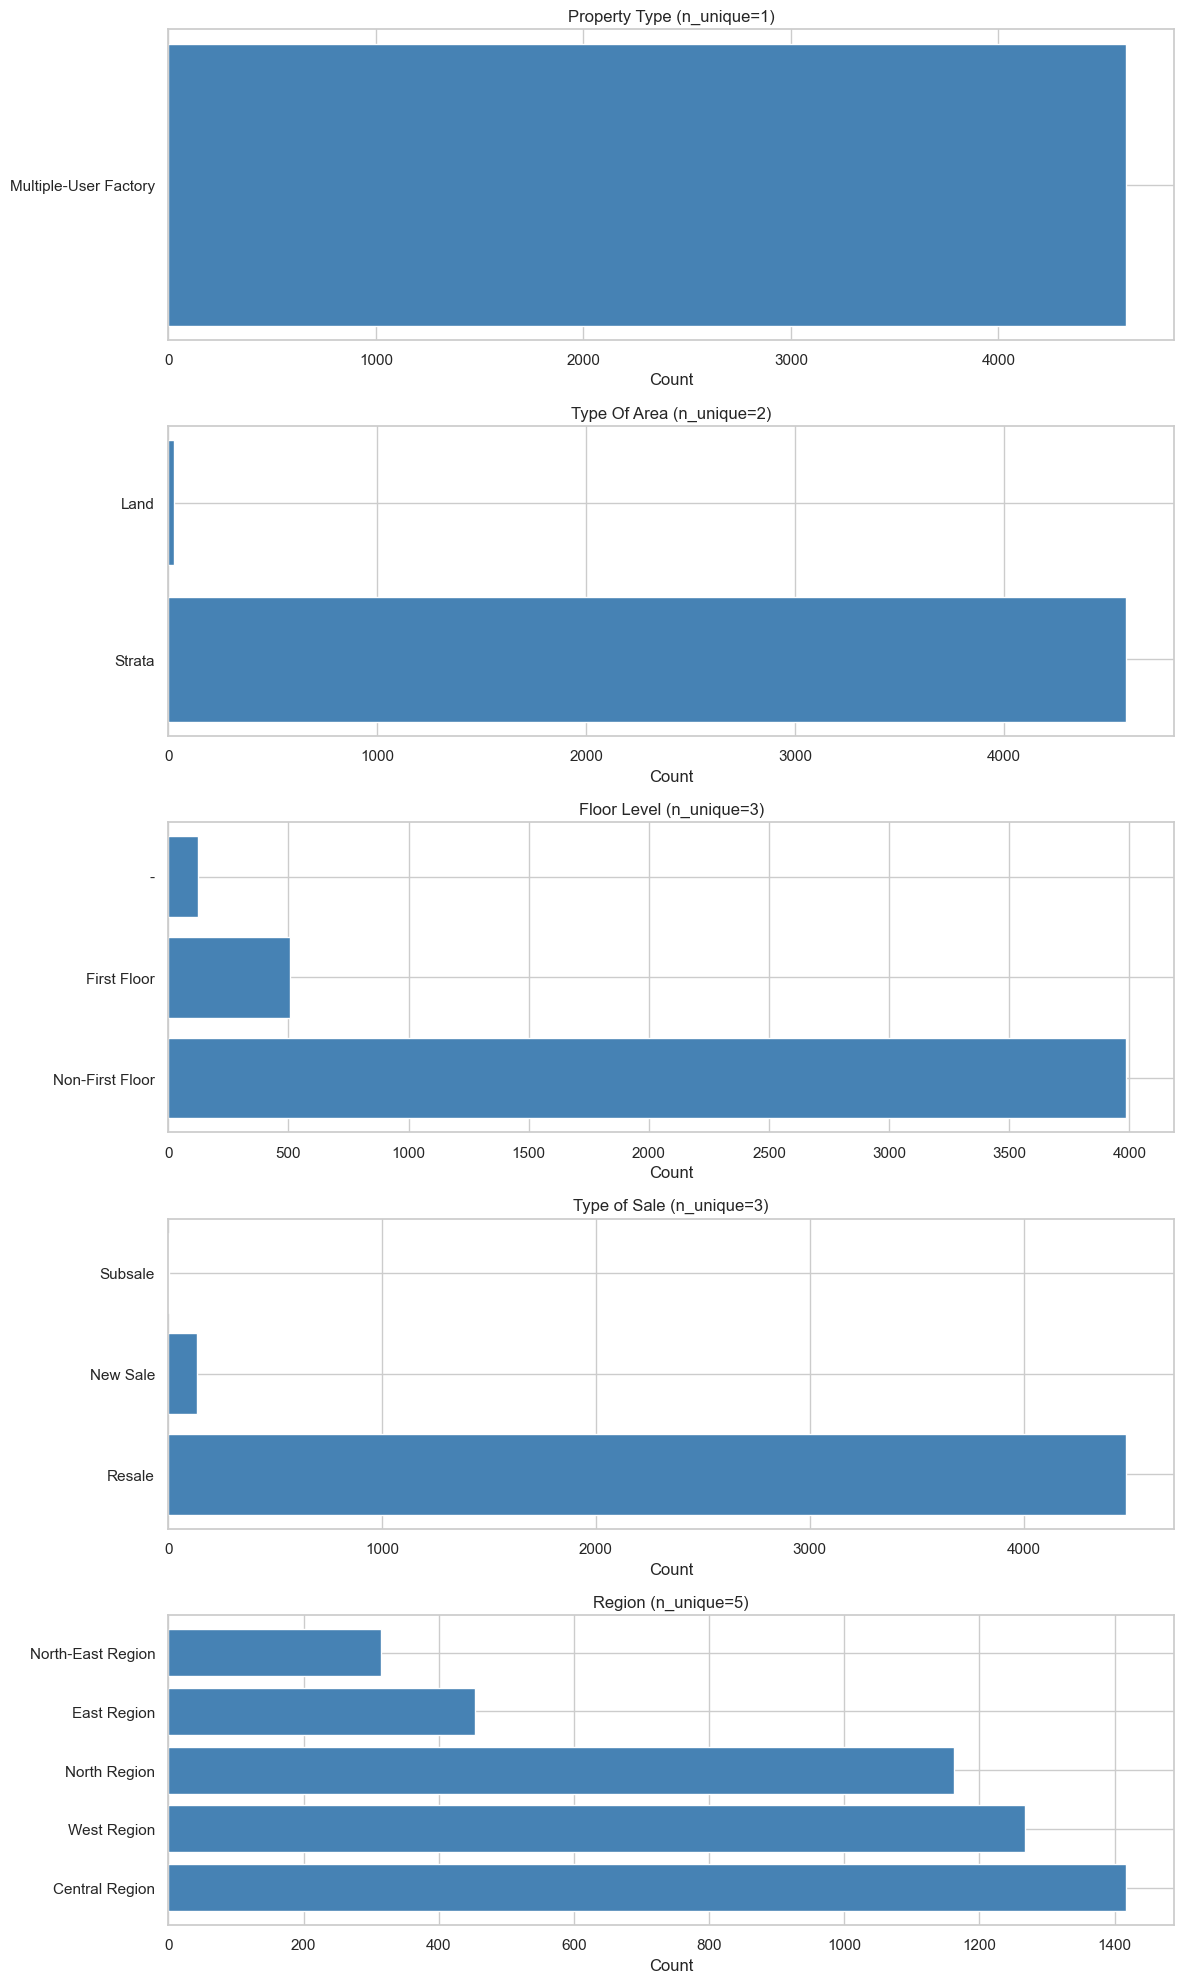

In [11]:
cat_cols = ["Property Type", "Type Of Area", "Floor Level", "Type of Sale", "Region"]

fig, axes = plt.subplots(len(cat_cols), 1, figsize=(12, 4 * len(cat_cols)))

for i, col in enumerate(cat_cols):
    counts = df[col].value_counts()
    axes[i].barh(counts.index, counts.values, color="steelblue")
    axes[i].set_title(f"{col} (n_unique={df[col].nunique()})")
    axes[i].set_xlabel("Count")

plt.tight_layout()
plt.show()

## 8. Tenure Breakdown

Tenure has mixed formats — let's see what we're working with.

In [12]:
# Look at unique tenure patterns
print(f"Unique tenure values: {df['Tenure'].nunique()}\n")
print("Sample values:")
for val in df["Tenure"].unique()[:20]:
    print(f"  {val}")

Unique tenure values: 130

Sample values:
  Freehold
  60 yrs from 15/12/2010
  60 yrs from 04/01/1999
  30 yrs from 01/04/2002
  30 yrs from 20/03/2015
  60 yrs from 09/07/1996
  60 yrs from 27/09/2011
  60 yrs from 13/03/1997
  99 yrs from 01/07/1962
  20 yrs from 19/09/2016
  60 yrs from 10/03/1997
  60 yrs from 01/01/2007
  30 yrs from 12/12/2005
  30 yrs from 25/07/2018
  999 yrs from 06/07/1885
  60 yrs from 01/12/1997
  60 yrs from 06/03/2009
  30 yrs from 01/04/2007
  60 yrs from 09/10/1999
  60 yrs from 23/01/2008


In [13]:
# Categorise tenure into broad groups
def categorise_tenure(val):
    if pd.isna(val):
        return "Unknown"
    val = str(val)
    if "Freehold" in val:
        return "Freehold"
    elif "999" in val:
        return "999-year"
    elif "99 yrs" in val:
        return "99-year"
    elif "60 yrs" in val:
        return "60-year"
    elif "30 yrs" in val:
        return "30-year"
    elif "20 yrs" in val:
        return "20-year"
    else:
        return "Other"

tenure_cat = df["Tenure"].apply(categorise_tenure)
print(tenure_cat.value_counts())

Tenure
60-year     2207
30-year     1140
Freehold     672
999-year     248
Other        199
99-year      147
20-year        2
Name: count, dtype: int64


## 9. Price by Key Categories

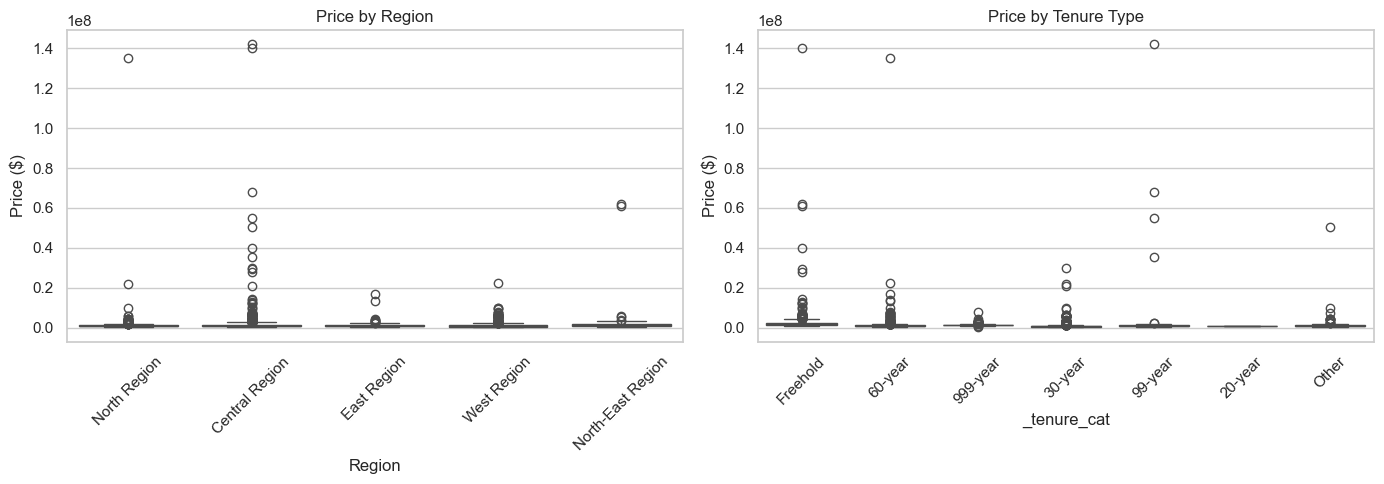

In [14]:
# Price by Region
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_temp = df.copy()
df_temp["_price"] = price_numeric
df_temp["_tenure_cat"] = tenure_cat

sns.boxplot(data=df_temp, x="Region", y="_price", ax=axes[0])
axes[0].set_title("Price by Region")
axes[0].set_ylabel("Price ($)")
axes[0].tick_params(axis="x", rotation=45)

# Price by Tenure Category
sns.boxplot(data=df_temp, x="_tenure_cat", y="_price", ax=axes[1])
axes[1].set_title("Price by Tenure Type")
axes[1].set_ylabel("Price ($)")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

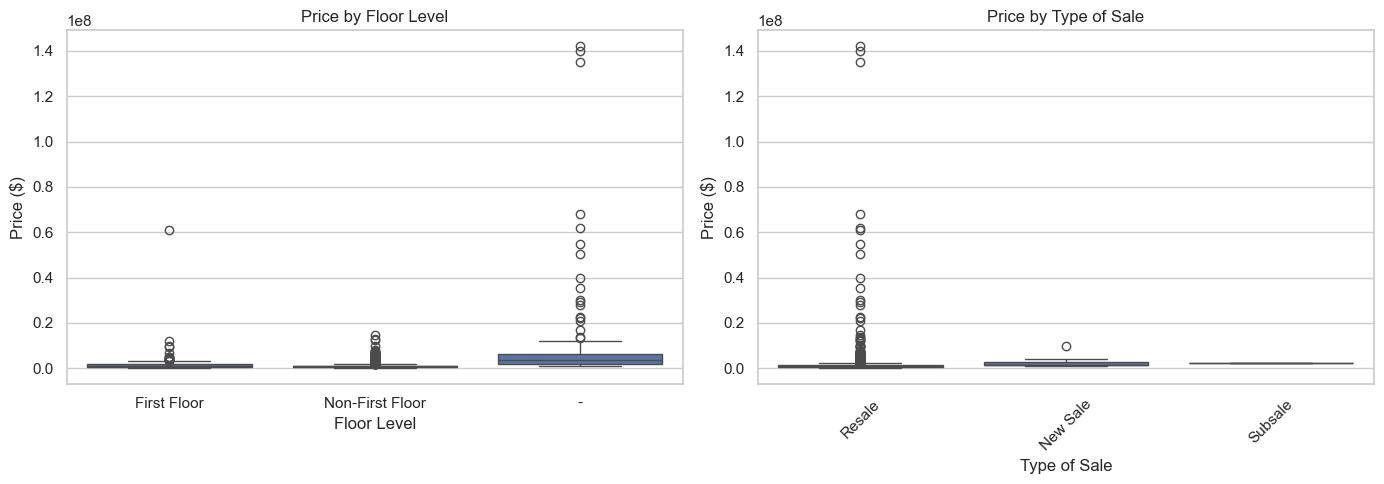

In [15]:
# Price by Floor Level
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df_temp, x="Floor Level", y="_price", ax=axes[0])
axes[0].set_title("Price by Floor Level")
axes[0].set_ylabel("Price ($)")

# Price by Type of Sale
sns.boxplot(data=df_temp, x="Type of Sale", y="_price", ax=axes[1])
axes[1].set_title("Price by Type of Sale")
axes[1].set_ylabel("Price ($)")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## 10. Area vs Price Scatter

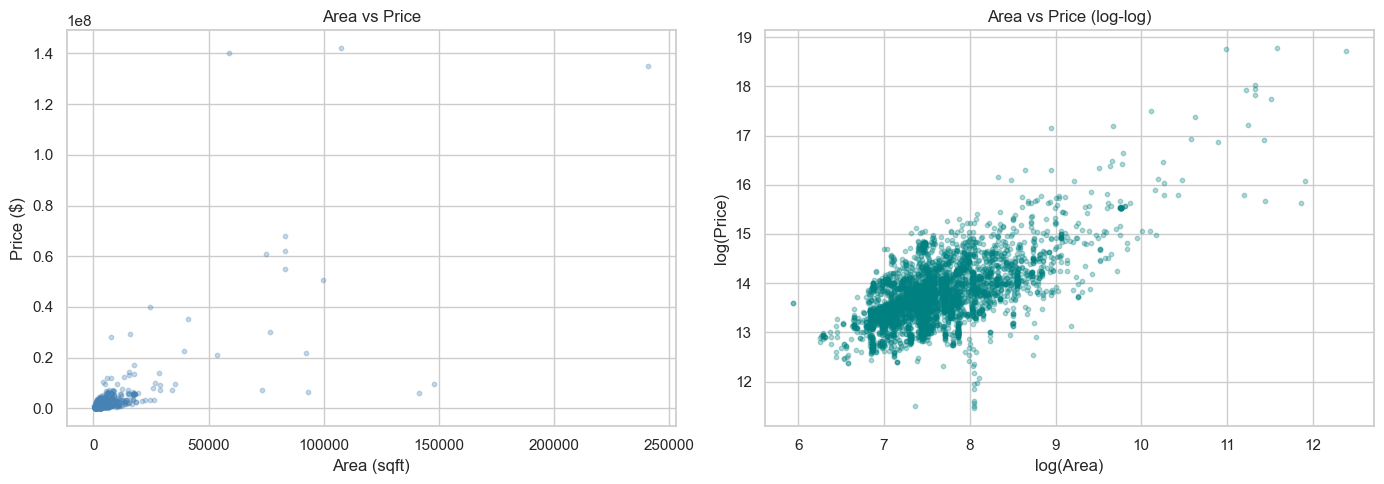

Correlation (Area vs Price): 0.7333


In [16]:
area_numeric = df["Area (sqft)"].str.replace(",", "").astype(float)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(area_numeric, price_numeric, alpha=0.3, s=10, color="steelblue")
axes[0].set_xlabel("Area (sqft)")
axes[0].set_ylabel("Price ($)")
axes[0].set_title("Area vs Price")

# Log-log scale
axes[1].scatter(np.log1p(area_numeric), np.log1p(price_numeric), alpha=0.3, s=10, color="teal")
axes[1].set_xlabel("log(Area)")
axes[1].set_ylabel("log(Price)")
axes[1].set_title("Area vs Price (log-log)")

plt.tight_layout()
plt.show()

print(f"Correlation (Area vs Price): {area_numeric.corr(price_numeric):.4f}")

## 11. Transactions Over Time

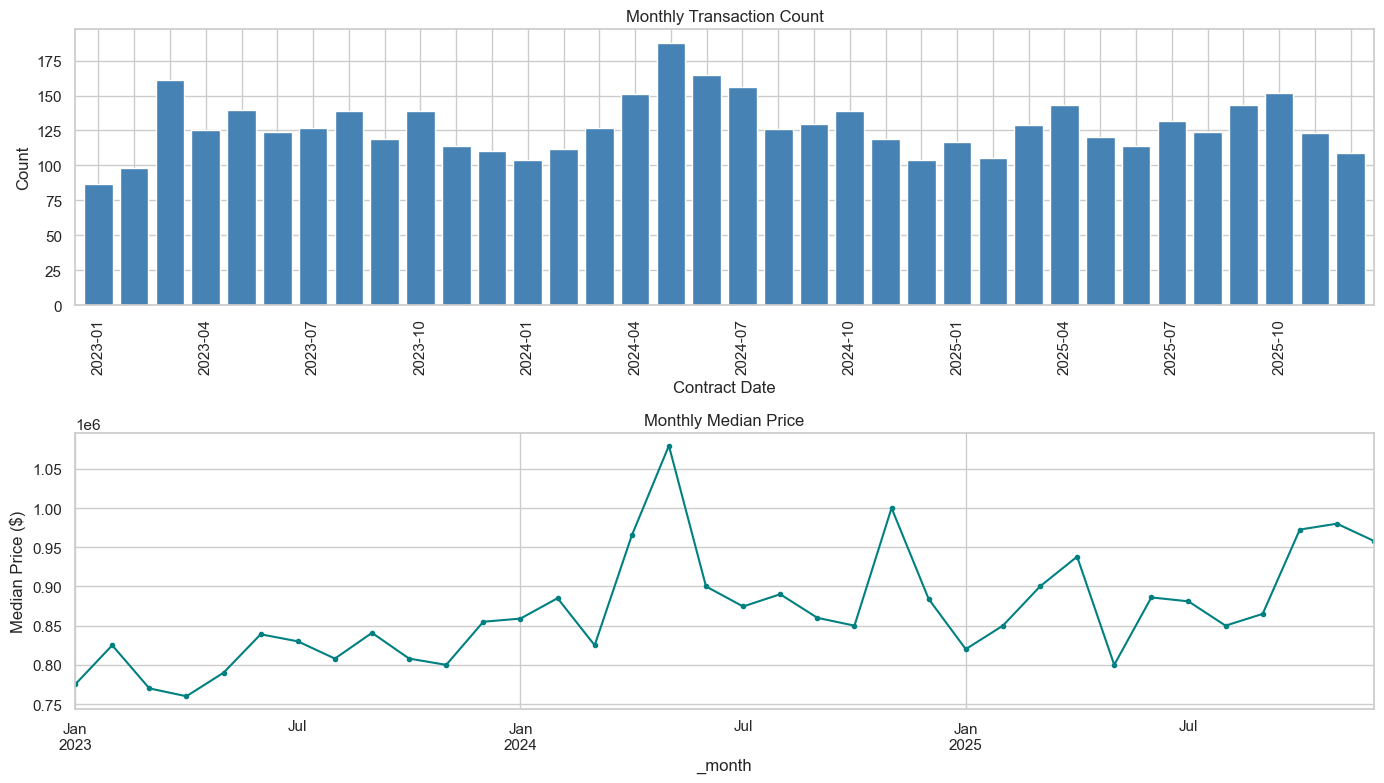

In [17]:
contract_date = pd.to_datetime(df["Contract Date"], dayfirst=True)
monthly = contract_date.dt.to_period("M").value_counts().sort_index()

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Transaction count over time
monthly.plot(kind="bar", ax=axes[0], color="steelblue", width=0.8)
axes[0].set_title("Monthly Transaction Count")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=90)
# Show every 3rd label
for i, label in enumerate(axes[0].xaxis.get_ticklabels()):
    if i % 3 != 0:
        label.set_visible(False)

# Median price over time
df_temp["_date"] = contract_date
df_temp["_month"] = contract_date.dt.to_period("M")
monthly_price = df_temp.groupby("_month")["_price"].median().sort_index()
monthly_price.plot(ax=axes[1], color="teal", marker="o", markersize=3)
axes[1].set_title("Monthly Median Price")
axes[1].set_ylabel("Median Price ($)")

plt.tight_layout()
plt.show()

## 12. Planning Area — Top 20 by Transaction Count

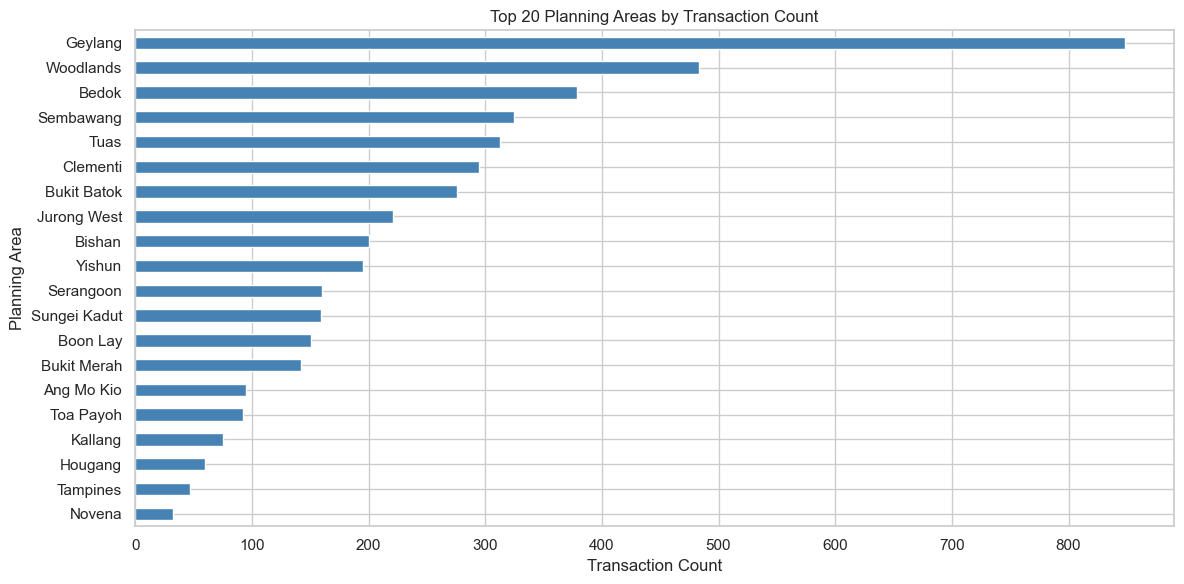

In [18]:
top_areas = df["Planning Area"].value_counts().head(20)

fig, ax = plt.subplots(figsize=(12, 6))
top_areas.plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("Transaction Count")
ax.set_title("Top 20 Planning Areas by Transaction Count")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 13. Initial Observations & Issues

**Run all cells above first**, then document findings here.

### Known issues to investigate after running:

1. **Commas in numeric columns** — `Price`, `Area (sqft)`, `Unit Price ($ psf)` are strings, need conversion
2. **Tenure parsing** — mixed formats (Freehold, "X yrs from DD/MM/YYYY"), need to extract tenure type + remaining lease years
3. **Contract Date** — stored as string, needs datetime conversion
4. **Floor Level** — has "-" values (unknown/missing)
5. **Unit Price ($ psf)** — potential data leakage if used as a feature (derived from Price / Area)
6. **Duplicates** — check if exact dupes exist and whether they're legitimate (e.g., multiple units same price)
7. **High-cardinality categoricals** — Project Name, Street Name, Planning Area may need grouping or encoding strategy